# Feature 527 (block down.2.1) heatmap across races

Feature 527 dominated the `disparity` ranking for almost every race in `sae_race_feature_analysis.ipynb`,
which is a red flag for an outlier/dead latent rather than a real racial signal (see
`baseline/sae_features/race_feature_prevalence.csv`). This notebook generates one image per race
with the same deterministic recipe used there, runs the pretrained SAE for `down.2.1`, and overlays
feature 527's activation map on the image so we can see what it actually fires on.

Outputs go to `baseline/heatmaps/`.

In [1]:
import os
os.chdir('/n/fs/goose/ReNO')

import sys
sys.path.append('/n/fs/goose/sdxl-unbox')

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from pytorch_lightning import seed_everything

from diffusers import AutoencoderKL, EulerAncestralDiscreteScheduler
from SDLens import HookedStableDiffusionXLPipeline
from SAE import SparseAutoencoder
from models.utils import get_model

/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.2.2+cu121)
    Python  3.10.14 (you have 3.10.20)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


In [2]:
# Config -- matches sae_race_feature_analysis.ipynb
MODEL = 'sdxl-turbo'
CACHE_DIR = 'hf_cache'
SEED = 0            # which of the N_SEEDS=50 samples to visualize per race
N_INFERENCE_STEPS = 1
DTYPE = torch.float16
DEVICE = torch.device('cuda')

FEATURE_IDX = 527
CODE = 'down.2.1'

CODE_TO_BLOCK = {
    "down.2.1": "unet.down_blocks.2.attentions.1",
    "mid.0": "unet.mid_block.attentions.0",
    "up.0.0": "unet.up_blocks.0.attentions.0",
    "up.0.1": "unet.up_blocks.0.attentions.1",
}
CHECKPOINT_DIR = '/n/fs/goose/sdxl-unbox/checkpoints'
OUT_DIR = '/n/fs/goose/baseline/heatmaps'
os.makedirs(OUT_DIR, exist_ok=True)

RACES = ["black", "white", "east asian", "middle eastern", "indian", "hispanic"]
GENDER = "woman"  # pick one gender for the comparison grid; change if you want
PROMPT_TEMPLATE = (
    "a portrait of a {race} {gender} with a neutral expression, "
    "without any facial coverings, in a neutral white colored t-shirt against a neutral white background"
)

In [3]:
import re

def slugify(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")

In [4]:
hooked_vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", torch_dtype=DTYPE, cache_dir=CACHE_DIR,
)
hooked_pipe = HookedStableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo", vae=hooked_vae, torch_dtype=DTYPE, variant="fp16",
    use_safetensors=True, cache_dir=CACHE_DIR,
)
hooked_pipe.pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
    hooked_pipe.pipe.scheduler.config, timestep_spacing="trailing",
)
hooked_pipe.pipe = hooked_pipe.pipe.to(DEVICE, DTYPE)

sae = SparseAutoencoder.load_from_disk(
    os.path.join(CHECKPOINT_DIR, f"{CODE_TO_BLOCK[CODE]}_k10_hidden5120_auxk256_bs4096_lr0.0001", "final")
).to(DEVICE)
n_dirs = sae.n_dirs
print("n_dirs:", n_dirs)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:  14%|█▍        | 1/7 [00:00<00:03,  1.51it/s]

Loading pipeline components...:  43%|████▎     | 3/7 [00:00<00:00,  4.68it/s]

Loading pipeline components...:  86%|████████▌ | 6/7 [00:01<00:00,  7.16it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.72it/s]

n_dirs: 5120


In [5]:
def make_heatmap_overlay(image: Image.Image, feature_map: np.ndarray, upscale: int) -> Image.Image:
    """feature_map: [h, w] SAE activations for one feature. Same jet/alpha-composite
    recipe as sdxl-unbox/app.py:plot_image_heatmap so results are visually comparable
    to what the Explore tab shows."""
    heatmap = np.kron(feature_map, np.ones((upscale, upscale)))
    image = image.convert("RGBA")

    jet = plt.cm.jet
    cmap = jet(np.arange(jet.N))
    cmap[:1, -1] = 0
    cmap[1:, -1] = 0.6
    cmap = ListedColormap(cmap)

    denom = np.max(heatmap) - np.min(heatmap)
    heatmap = (heatmap - np.min(heatmap)) / denom if denom > 0 else np.zeros_like(heatmap)
    heatmap_rgba = cmap(heatmap)
    heatmap_image = Image.fromarray((heatmap_rgba * 255).astype(np.uint8)).resize(image.size)

    return Image.alpha_composite(image, heatmap_image)

In [6]:
results = {}

for race in RACES:
    prompt = PROMPT_TEMPLATE.format(race=race, gender=GENDER)
    seed_everything(SEED)
    generator = torch.Generator("cuda").manual_seed(SEED)
    latents = torch.randn((1, 4, 64, 64), device=DEVICE, dtype=DTYPE)

    with torch.no_grad():
        images, cache = hooked_pipe.run_with_cache(
            prompt,
            latents=latents,
            generator=generator,
            num_inference_steps=N_INFERENCE_STEPS,
            guidance_scale=0.0,
            positions_to_cache=[CODE_TO_BLOCK[CODE]],
            save_input=True,
            save_output=True,
        )
    image = images.images[0]

    block = CODE_TO_BLOCK[CODE]
    diff = cache["output"][block] - cache["input"][block]
    if diff.shape[0] == 2:
        diff = diff[1].unsqueeze(0)
    # [batch, T, d_model, h, w] -> take last timestep -> [h, w, d_model]
    diff_last = diff[:, -1].permute(0, 2, 3, 1).squeeze(0)
    h, w, d_model = diff_last.shape

    with torch.no_grad():
        feats = sae.encode(diff_last.reshape(-1, d_model).float().to(DEVICE))
    feature_map = feats[:, FEATURE_IDX].reshape(h, w).cpu().numpy()

    upscale = image.size[0] // w
    overlay = make_heatmap_overlay(image, feature_map, upscale)

    out_path = os.path.join(OUT_DIR, f"feature{FEATURE_IDX}_{CODE}_{slugify(race)}.png")
    overlay.save(out_path)

    results[race] = {
        "image": image,
        "overlay": overlay,
        "feature_map": feature_map,
        "max_activation": float(feature_map.max()),
        "path": out_path,
    }
    print(f"{race:15s} max_activation={results[race]['max_activation']:.3f}  -> {out_path}")

[rank: 0] Seed set to 0


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.29it/s]

100%|██████████| 1/1 [00:00<00:00,  3.28it/s]

[rank: 0] Seed set to 0


...

[rank: 0] Seed set to 0


indian          max_activation=13.000  -> /n/fs/goose/baseline/heatmaps/feature527_down.2.1_indian.png


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 15.00it/s]

hispanic        max_activation=16.063  -> /n/fs/goose/baseline/heatmaps/feature527_down.2.1_hispanic.png


saved grid -> /n/fs/goose/baseline/heatmaps/feature527_down.2.1_grid.png


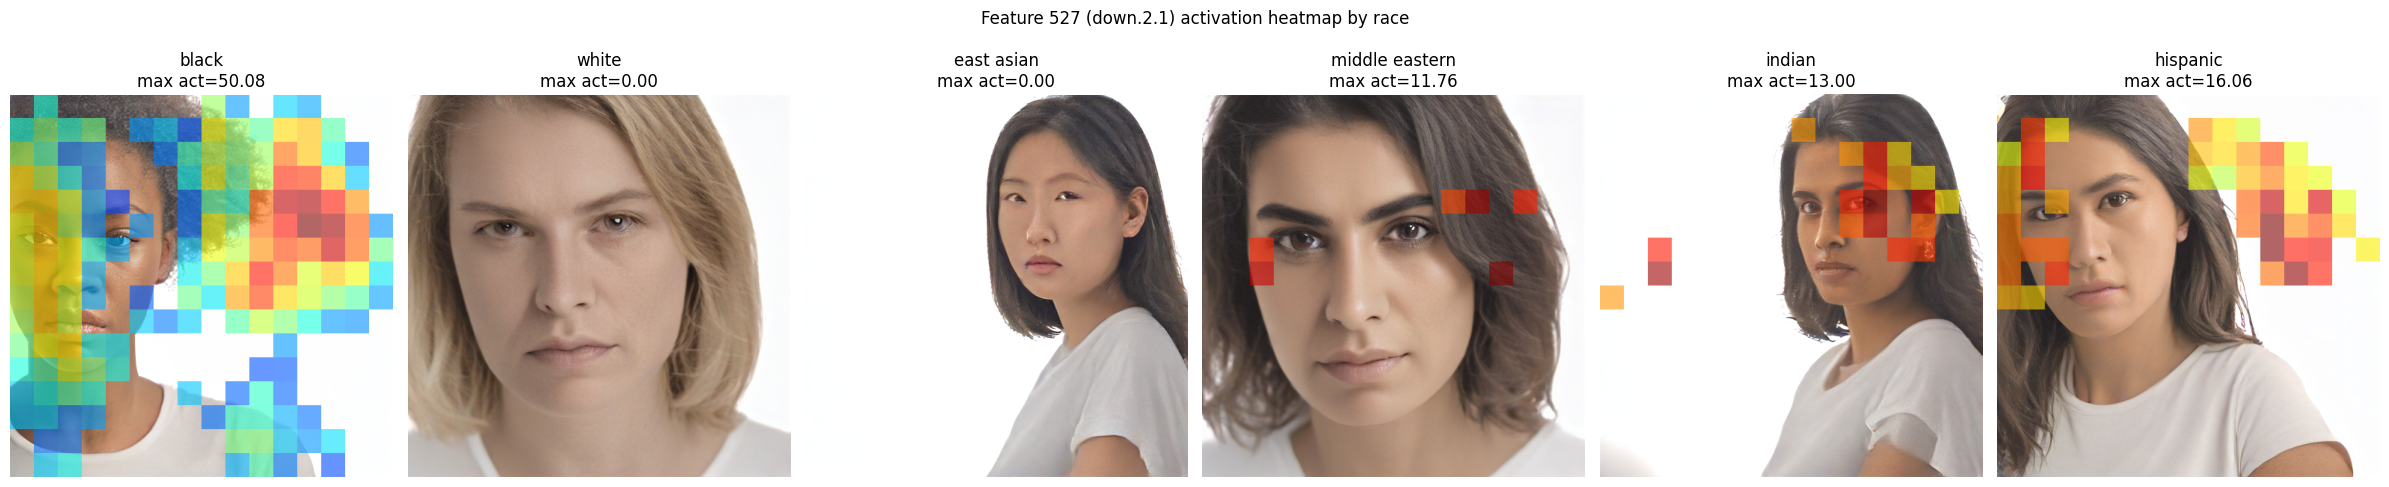

In [7]:
fig, axes = plt.subplots(1, len(RACES), figsize=(4 * len(RACES), 5))
for ax, race in zip(axes, RACES):
    ax.imshow(results[race]["overlay"])
    ax.set_title(f"{race}\nmax act={results[race]['max_activation']:.2f}")
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(f"Feature {FEATURE_IDX} ({CODE}) activation heatmap by race", y=1.02)
fig.tight_layout()
grid_path = os.path.join(OUT_DIR, f"feature{FEATURE_IDX}_{CODE}_grid.png")
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
print("saved grid ->", grid_path)
plt.show()